<a href="https://colab.research.google.com/github/NP-Env/MMR_Classification/blob/main/MMRClassifier_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


⏳ Running: BART (Meta) ...


Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

✅ Done: BART (Meta)

⏳ Running: DeBERTa (Microsoft) ...


Loading weights:   0%|          | 0/394 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: cross-encoder/nli-deberta-v3-large
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

✅ Done: RoBERTa (Meta)

CONFIDENCE SCORES BY MODEL (%) — sorted by confidence

BART (Meta)
----------------------------------------
  record keeping        65.0%  █████████████
  reporting             14.4%  ██
  monitoring            12.4%  ██
  notification           6.6%  █
  mitigation             1.7%  

DeBERTa (Microsoft)
----------------------------------------
  reporting             47.7%  █████████
  record keeping        43.0%  ████████
  monitoring             9.1%  █
  notification           0.1%  
  mitigation             0.0%  

DeBERTa ZS (Laurer)
----------------------------------------
  record keeping        54.8%  ██████████
  reporting             22.6%  ████
  monitoring            21.1%  ████
  notification           1.1%  
  mitigation             0.4%  

Flan-T5 (Google)
----------------------------------------
  reporting             21.4%  ████
  record keeping        20.3%  ████
  monitoring            20.2%  ████
  mitigation            19.1%  ███
  notifi

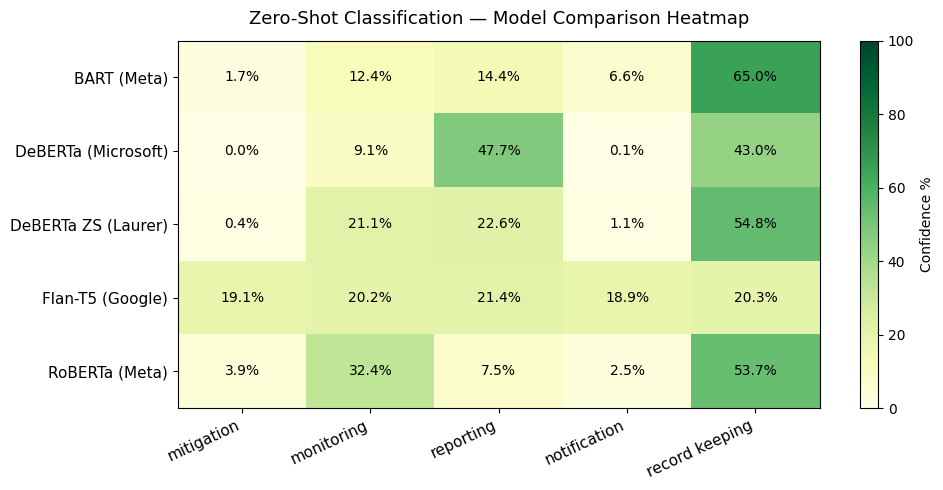


TOP MODEL PER LABEL
  mitigation           → Flan-T5 (Google)               (19.1%)
  monitoring           → RoBERTa (Meta)                 (32.4%)
  reporting            → DeBERTa (Microsoft)            (47.7%)
  notification         → Flan-T5 (Google)               (18.9%)
  record keeping       → BART (Meta)                    (65.0%)


In [3]:
# ── 1. Install ──────────────────────────────────────────────────────────────
!pip install transformers torch --quiet

# ── 2. Imports ───────────────────────────────────────────────────────────────
from transformers import pipeline
import pandas as pd

# ── 3. Setup ─────────────────────────────────────────────────────────────────
labels = ["mitigation", "monitoring", "reporting", "notification", "record keeping"]
text = "The permittee shall calculate and maintain monthly records of the VOC emissions and the rolling 12-month emissions of VOC."

models = {
    "BART (Meta)"        : "facebook/bart-large-mnli",
    "DeBERTa (Microsoft)": "cross-encoder/nli-deberta-v3-large",
    "DeBERTa ZS (Laurer)": "MoritzLaurer/deberta-v3-base-zeroshot-v1",
    "Flan-T5 (Google)"   : "google/flan-t5-large",
    "RoBERTa (Meta)"     : "roberta-large-mnli",
}

# ── 4. Run all models ─────────────────────────────────────────────────────────
results = {}

for name, model_id in models.items():
    print(f"\n⏳ Running: {name} ...")
    classifier = pipeline("zero-shot-classification", model=model_id)
    output = classifier(text, labels)
    results[name] = dict(zip(output["labels"], output["scores"]))
    print(f"✅ Done: {name}")

# ── 5. Build comparison DataFrame ────────────────────────────────────────────
df = pd.DataFrame(results).T          # rows = models, cols = labels
df = df[labels]                        # keep original label order
df_pct = (df * 100).round(1)          # convert to percentage

# ── 6. Print ranked table per model ──────────────────────────────────────────
print("\n" + "="*65)
print("CONFIDENCE SCORES BY MODEL (%) — sorted by confidence")
print("="*65)

for model_name, row in df_pct.iterrows():
    print(f"\n{model_name}")
    print("-" * 40)
    for label, score in row.sort_values(ascending=False).items():
        bar = "█" * int(score / 5)
        print(f"  {label:20s} {score:5.1f}%  {bar}")

# ── 7. Heatmap comparison (visual) ────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 5))
data = df_pct.values
im = ax.imshow(data, cmap="YlGn", aspect="auto", vmin=0, vmax=100)

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=25, ha="right", fontsize=11)
ax.set_yticks(range(len(df_pct)))
ax.set_yticklabels(df_pct.index, fontsize=11)

for i in range(len(df_pct)):
    for j in range(len(labels)):
        ax.text(j, i, f"{data[i, j]:.1f}%",
                ha="center", va="center", fontsize=10,
                color="black" if data[i, j] < 70 else "white")

plt.colorbar(im, ax=ax, label="Confidence %")
ax.set_title("Zero-Shot Classification — Model Comparison Heatmap", fontsize=13, pad=12)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150)
plt.show()

# ── 8. Print winner per label ─────────────────────────────────────────────────
print("\n" + "="*65)
print("TOP MODEL PER LABEL")
print("="*65)
for label in labels:
    winner = df_pct[label].idxmax()
    score  = df_pct[label].max()
    print(f"  {label:20s} → {winner:30s} ({score:.1f}%)")